## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [3]:
# ritorna la frequenza assoluta delle volte che è uscita testa dal lancio di una moneta
def simula_lancio_numpy(N):
    lanci = np.random.randint(0, 2, size=N)
    return lanci.mean() * 100


In [4]:
# calcolare la freq % con la grandezza del campione(numero di lanci), che varia da 10 a 20000, (prendo 100 valori nel range)
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)
df

,0,1
0,10,70.000000
1,210,55.714286
2,410,52.926829
3,610,55.737705
4,810,47.530864
...,...,...
95,19010,49.936875
96,19210,49.838626
97,19410,50.407007
98,19610,50.127486


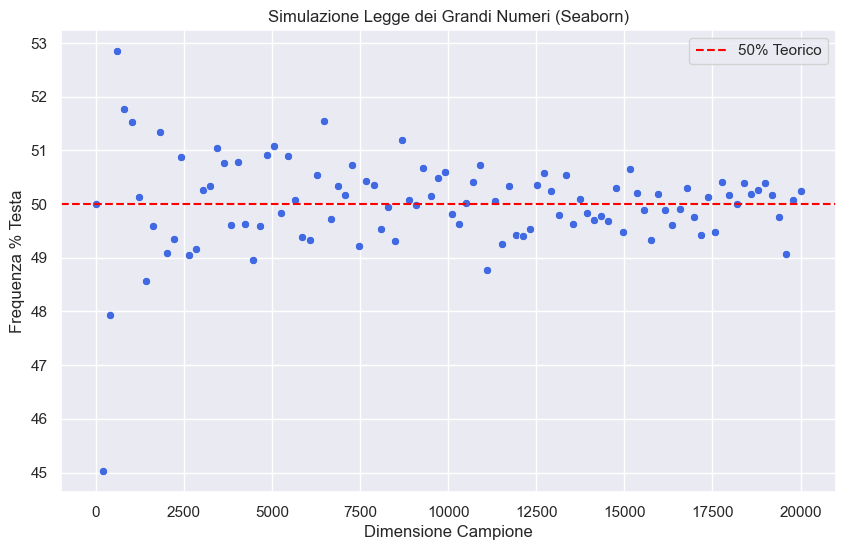

In [5]:
# 1. Funzione di simulazione
def frequenza_testa(n):
    return np.random.randint(0, 2, size=n).mean() * 100

# 2. Creazione dei dati
campione_n = np.linspace(10, 20000, 100, dtype=int)
frequenze = [frequenza_testa(n) for n in campione_n]
df_simulazione = pd.DataFrame({
    'Dimensione Campione': campione_n,
    'Frequenza % Testa': frequenze
})

# 3. Visualizzazione con Seaborn
sns.set_theme(style="darkgrid") # Imposta un tema moderno
plt.figure(figsize=(10, 6))

# Creazione del lineplot
sns.scatterplot(data=df_simulazione, x='Dimensione Campione', y='Frequenza % Testa', color='royalblue')

# Aggiunta della linea teorica (Matplotlib si integra perfettamente)
plt.axhline(50, color='red', linestyle='--', label='50% Teorico')

plt.title("Simulazione Legge dei Grandi Numeri (Seaborn)")
plt.legend()
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [6]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape


(891, 12)

In [8]:
mancanti_per_colonna = df.isna().sum()
mancanti_per_colonna

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
import statistics as st
df["Embarked"] = df["Embarked"].fillna(st.mode(df[df["Embarked"].notna()]["Embarked"]))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.8 KB


In [10]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [11]:
media_by_Pclass = df.groupby("Pclass")["Age"].mean(skipna=True)
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.8 KB


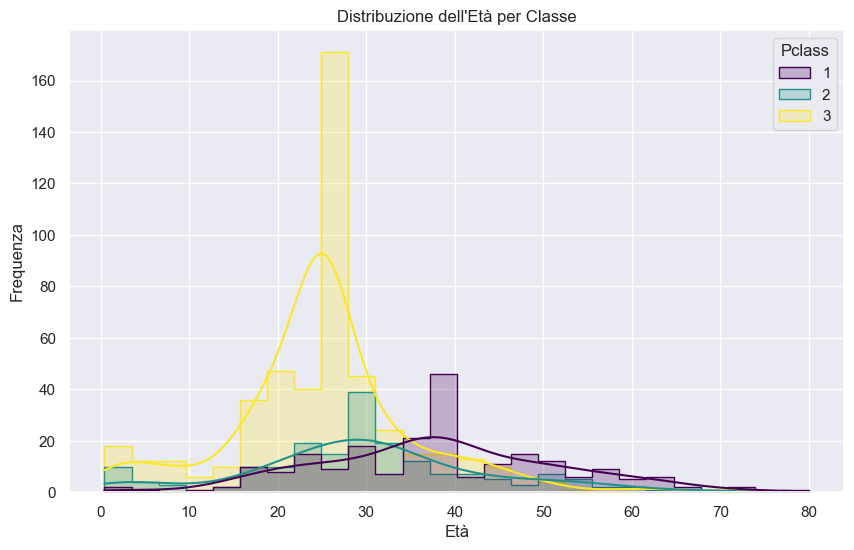

In [12]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Age", hue="Pclass", kde=True, element="step", palette="viridis")

plt.title("Distribuzione dell'Età per Classe")
plt.xlabel("Età")
plt.ylabel("Frequenza")
plt.show()


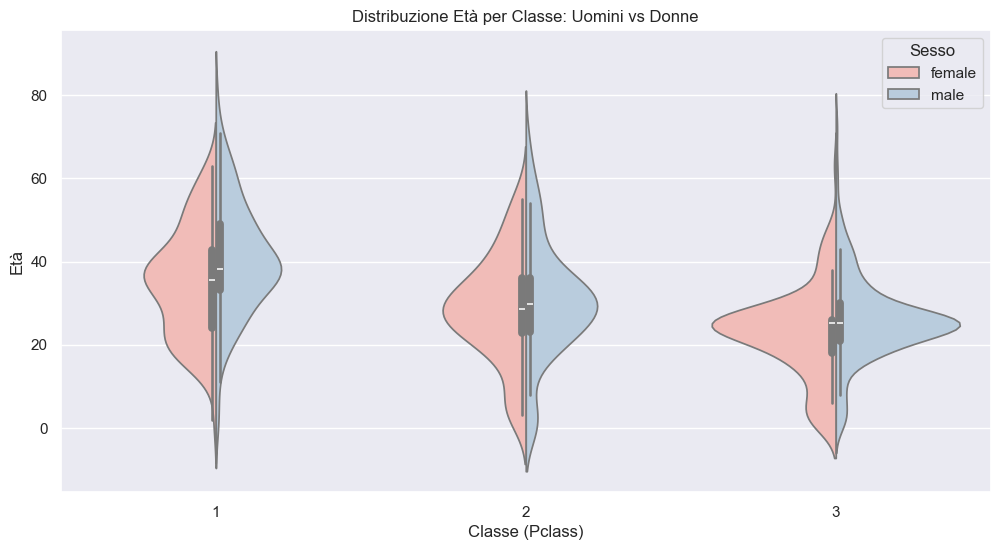

In [19]:
plt.figure(figsize=(12, 6))
# Usiamo un Violin Plot o un Box Plot con l'argomento 'hue' per dividere uomini e donne
sns.violinplot(data=df, x='Pclass', y='Age', hue='Sex',split=True, palette='Pastel1')

plt.title("Distribuzione Età per Classe: Uomini vs Donne")
plt.xlabel("Classe (Pclass)")
plt.ylabel("Età")
plt.legend(title='Sesso')
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
df.groupby("species").count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,50,50,50,50
versicolor,50,50,50,50
virginica,50,50,50,50


In [54]:
df_means = df.groupby("species").mean(skipna=True).iloc[:, 2:4]
df_means 

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


Text(0, 0.5, 'petal_width')

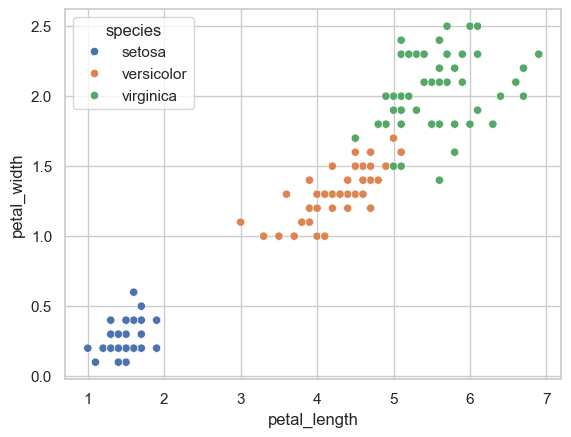

In [ ]:
sns.set_style("whitegrid")
sns.scatterplot(data=df, x="petal_length",y="petal_width",hue="species")
plt.xlabel(xlabel="petal_length")
plt.ylabel(ylabel="petal_width")

In [64]:
df["area_petalo"]=df["petal_length"]*df["petal_width"]
df["area_petalo"].describe()

count    150.000000
mean       5.794067
std        4.712390
min        0.110000
25%        0.420000
50%        5.615000
75%        9.690000
max       15.870000
Name: area_petalo, dtype: float64

<Axes: xlabel='area_petalo'>

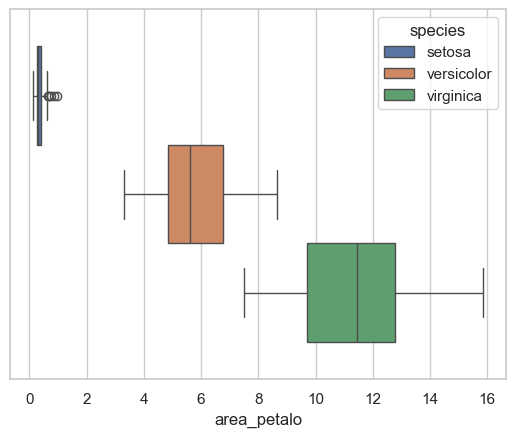

In [70]:
sns.boxplot(data=df,x="area_petalo", hue="species")